A fintech company provides instant personal loans through a mobile application.
To reduce risk, the company wants an AI-based decision system that predicts whether a loan should be Approved or Rejected.
Challenges:
-   Customer data is not linearly separable
    - Simple linear rules fail
    - Decision boundaries may be curved or complex
    - The solution must be interactive and deployable
    - You are hired as a Machine Learning Engineer to build and deploy this system.

Load the dataset and study applicant attributes such as:
-    Applicant income
-    Loan amount
-    Credit history
-    Employment status
#
   Identify features that may influence loan approval

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df=pd.read_csv('train_u6lujuX_CVtuZ9i.csv')

In [30]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [31]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [32]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [33]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)


C:\Users\reshmitha\AppData\Local\Temp\ipykernel_4068\1669564486.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
C:\Users\reshmitha\AppData\Local\Temp\ipykernel_4068\1669564486.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [36]:
df.select_dtypes(['object'])

,Loan_ID
0,LP001002
1,LP001003
2,LP001005
3,LP001006
4,LP001008
...,...
609,LP002978
610,LP002979
611,LP002983
612,LP002984


In [35]:
df['Gender']=df['Gender'].map({'Male':0,'Female':1})
df['Married']=df['Married'].map({'No':0,'Yes':1})
df['Dependents']=df['Dependents'].map({'0':0,'1':1,'2':2,'3+':3})
df['Education']=df['Education'].map({'Not Graduate':0,'Graduate':1})
df['Self_Employed']=df['Self_Employed'].map({'No':0,'Yes':1})
df['Property_Area']=df['Property_Area'].map({'Rural':0,'Semiurban':1,'Urban':2})
df['Loan_Status']=df['Loan_Status'].map({'N':0,'Y':1})

In [37]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,1,0,0,1,0,2900,0.0,71.0,360.0,1.0,0,1
610,LP002979,0,1,3,1,0,4106,0.0,40.0,180.0,1.0,0,1
611,LP002983,0,1,1,1,0,8072,240.0,253.0,360.0,1.0,2,1
612,LP002984,0,1,2,1,0,7583,0.0,187.0,360.0,1.0,2,1


Property_Area
1    233
2    202
0    179
Name: count, dtype: int64

In [50]:
corr_matrix = df.select_dtypes(include='number').corr()

<Axes: >

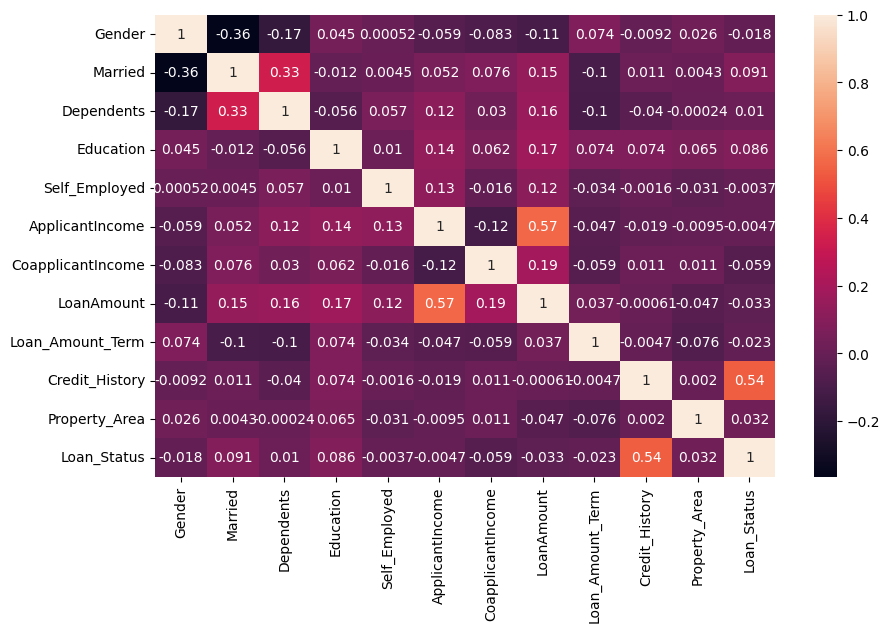

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,annot=True)

In [44]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
X=df[['ApplicantIncome','LoanAmount','Credit_History','Self_Employed']]
y=df['Loan_Status']

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler=StandardScaler()
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [58]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [61]:
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay
from sklearn.svm import SVC

r2_score =  0.7886178861788617
classification_report =
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



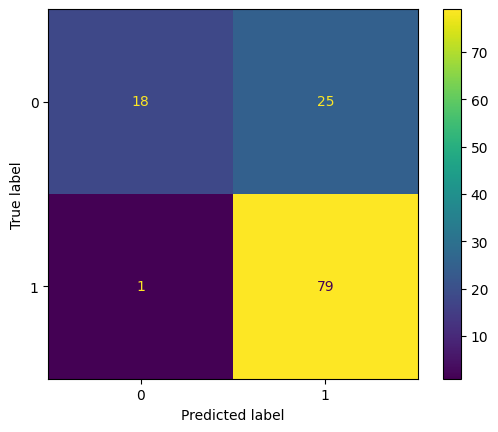

In [ ]:
svm_linear = SVC(kernel='linear',C=1)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
print('r2_score = ',accuracy_score(y_test,y_pred_linear))
print('classification_report =\n',classification_report(y_test,y_pred_linear))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_linear
)

r2_score =  0.7886178861788617
classification_report =
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



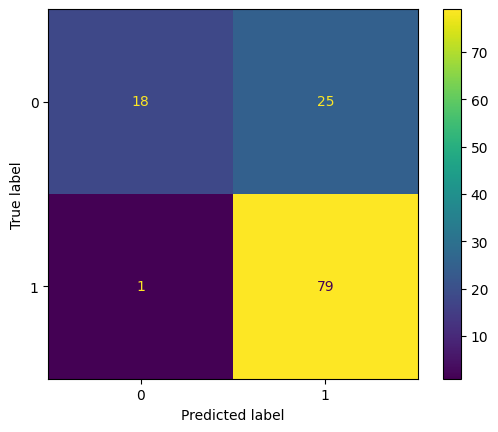

In [ ]:
svm_poly = SVC(kernel='poly', degree=3,C=1)
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)
print('r2_score = ',accuracy_score(y_test,y_pred_poly))
print('classification_report =\n',classification_report(y_test,y_pred_poly))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_poly
)

r2_score =  0.7967479674796748
classification_report =
               precision    recall  f1-score   support

           0       1.00      0.42      0.59        43
           1       0.76      1.00      0.86        80

    accuracy                           0.80       123
   macro avg       0.88      0.71      0.73       123
weighted avg       0.85      0.80      0.77       123



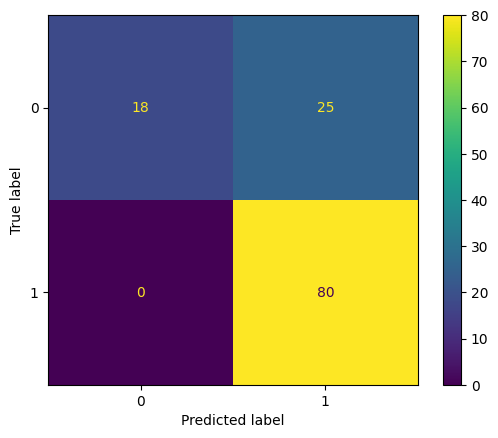

In [64]:
svm_rbf=SVC(kernel='rbf',gamma='scale',C=1)
svm_rbf.fit(X_train,y_train)
y_pred_rbf=svm_rbf.predict(X_test)
print('r2_score = ',accuracy_score(y_test,y_pred_rbf))
print('classification_report =\n',classification_report(y_test,y_pred_rbf))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rbf
)

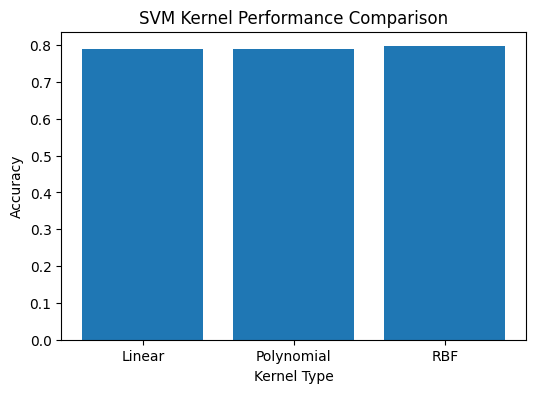

In [69]:
import matplotlib.pyplot as plt

accuracies = [
    accuracy_score(y_test, y_pred_linear),
    accuracy_score(y_test, y_pred_ploy),
    accuracy_score(y_test, y_pred_rbf)
]

kernels = ['Linear', 'Polynomial', 'RBF']

plt.figure(figsize=(6,4))
plt.bar(kernels, accuracies)
plt.title("SVM Kernel Performance Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Kernel Type")
plt.show()


In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rbf)

false_negatives = cm[1][0]  # Eligible rejected
false_positives = cm[0][1]  # Risky approved

print("Eligible customers rejected:", false_negatives)
print("Risky customers approved:", false_positives)


Eligible customers rejected: 0
Risky customers approved: 25
